## Generación de Números Aleatorios Uniformes
### Descripción: Este script implementa la generación de 100 números aleatorios uniformes
####              entre 0 y 25 utilizando el método congruencial lineal con la expresión:
              x_{i+1} = (73x_i + 851)mod17561, con x_0 = 329

In [30]:
# Cargar bibliotecas necesarias
library(ggplot2)
library(dplyr)

In [31]:
#---------------------------------------------------------------------------
# Función para generar números aleatorios usando el método congruencial lineal
#---------------------------------------------------------------------------
GenerarNumerosAleatorios <- function(n, p, mod, semilla, cantidad) {
  numerosAleatorios <- numeric(cantidad)
  x <- semilla

  for (i in 1:cantidad) {
    x <- (n * x + p) %% mod
    r <- x %% 26
    numerosAleatorios[i] <- r
  }

  return(numerosAleatorios)
}

In [32]:
#---------------------------------------------------------------------------
# Función para calcular estadísticas básicas
#---------------------------------------------------------------------------
CalcularEstadisticas <- function(datos) {
  resultados <- list(
    media = mean(datos),
    varianza = var(datos),
    desviacionEstandar = sd(datos),
    minimo = min(datos),
    maximo = max(datos),
    mediana = median(datos),
    cuartiles = quantile(datos, probs = c(0.25, 0.75))
  )

  return(resultados)
}

In [33]:
#---------------------------------------------------------------------------
# Función para generar gráficos
#---------------------------------------------------------------------------
GenerarGraficos <- function(datos) {
  # Crear un dataframe para facilitar el uso con ggplot2
  df <- data.frame(valor = datos)

  # Histograma
  histograma <- ggplot(df, aes(x = valor)) +
    geom_histogram(binwidth = 1, color = "black", fill = "skyblue", alpha = 0.7) +
    scale_x_continuous(breaks = 0:25) +
    labs(
      title = "Histograma de Números Aleatorios",
      subtitle = "Generados mediante x_{i+1} = (73x_i + 851)mod17561",
      x = "Valor",
      y = "Frecuencia"
    ) +
    theme_minimal() +
    theme(
      plot.title = element_text(hjust = 0.5, face = "bold"),
      plot.subtitle = element_text(hjust = 0.5),
      panel.grid.minor = element_blank(),
      panel.grid.major.x = element_blank()
    )

  # Gráfico de dispersión para verificar patrones
  dispersion <- ggplot(df, aes(x = 1:length(valor), y = valor)) +
    geom_line(color = "gray70", alpha = 0.6) +
    geom_point(color = "darkblue", size = 2, alpha = 0.7) +
    labs(
      title = "Secuencia de Números Aleatorios",
      x = "Posición",
      y = "Valor"
    ) +
    theme_minimal() +
    theme(
      plot.title = element_text(hjust = 0.5, face = "bold"),
      panel.grid.minor = element_blank()
    )

  # Prueba de autocorrelación
  autocorrelacion <- acf(df$valor, lag.max = 20, plot = FALSE)
  autocorrelacionPlot <- plot(autocorrelacion, main = "Autocorrelación de la Secuencia")

  return(list(histograma = histograma, dispersion = dispersion))
}

In [34]:
#---------------------------------------------------------------------------
# Función para evaluar la calidad de los números aleatorios
#---------------------------------------------------------------------------
EvaluarCalidad <- function(datos, esperado) {
  # Prueba Chi-cuadrado para uniformidad
  frecuenciaObservada <- table(factor(datos, levels = 0:25))
  frecuenciaEsperada <- rep(length(datos)/26, 26)

  chiCuadrado <- sum((frecuenciaObservada - frecuenciaEsperada)^2 / frecuenciaEsperada)
  gradosLibertad <- 25
  valorP <- 1 - pchisq(chiCuadrado, gradosLibertad)

  # Evaluar la distribución de frecuencias
  uniformidad <- if(valorP > 0.05) {
    "Los números generados parecen tener una distribución uniforme"
  } else {
    "Los números generados NO parecen tener una distribución uniforme"
  }

  # Calcular desviación de la media esperada
  desviacionMedia <- abs(mean(datos) - esperado)
  porcentajeDesviacion <- (desviacionMedia / esperado) * 100

  resultados <- list(
    chiCuadrado = chiCuadrado,
    valorP = valorP,
    uniformidad = uniformidad,
    desviacionMedia = desviacionMedia,
    porcentajeDesviacion = porcentajeDesviacion
  )

  return(resultados)
}

In [35]:
#---------------------------------------------------------------------------
# Parámetros del generador congruencial lineal
#---------------------------------------------------------------------------
# Parámetros del generador congruencial lineal según el enunciado:
# x_{i+1} = (73x_i + 851)mod17561, con x_0 = 329
parametros <- list(
  n = 73,
  p = 851,
  mod = 17561,
  semilla = 329,
  cantidad = 100
)

In [36]:
#---------------------------------------------------------------------------
# Ejecución principal
#---------------------------------------------------------------------------
# Generar números aleatorios
numerosAleatorios <- GenerarNumerosAleatorios(
  parametros$n,
  parametros$p,
  parametros$mod,
  parametros$semilla,
  parametros$cantidad
)

In [37]:
# Calcular estadísticas
estadisticas <- CalcularEstadisticas(numerosAleatorios)

In [38]:
# Evaluar calidad (valor esperado para distribución uniforme entre 0 y 25 es 12.5)
valorEsperado <- 12.5
calidadGenerador <- EvaluarCalidad(numerosAleatorios, valorEsperado)

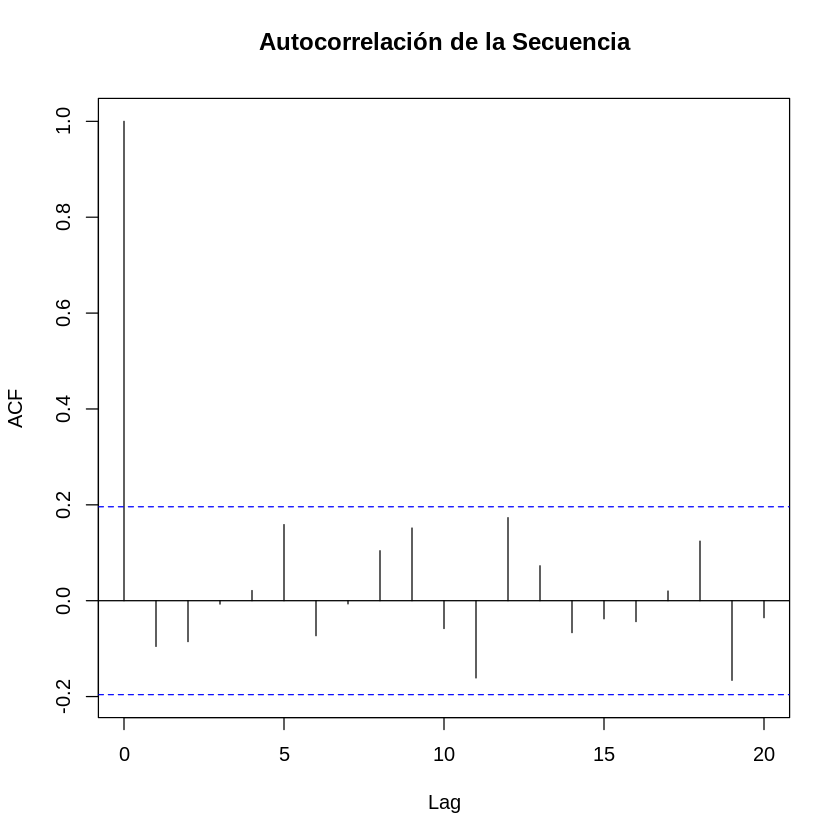

In [39]:
# Generar gráficos
graficos <- GenerarGraficos(numerosAleatorios)

In [40]:
#---------------------------------------------------------------------------
# Mostrar resultados
#---------------------------------------------------------------------------
cat("\n=== RESULTADOS DEL GENERADOR DE NÚMEROS ALEATORIOS ===\n")
cat("\nNúmeros aleatorios generados:\n")
print(numerosAleatorios)

cat("\n--- Estadísticas Básicas Solicitadas ---\n")
cat(sprintf("Valor esperado (media): %.4f (Teórico: %.4f)\n", estadisticas$media, valorEsperado))
cat(sprintf("Varianza: %.4f (Teórico para distribución uniforme: %.4f)\n",
            estadisticas$varianza, ((26-1)^2)/12))

cat("\n--- Estadísticas Adicionales ---\n")
cat(sprintf("Desviación Estándar: %.4f\n", estadisticas$desviacionEstandar))
cat(sprintf("Mínimo: %d\n", estadisticas$minimo))
cat(sprintf("Máximo: %d\n", estadisticas$maximo))
cat(sprintf("Mediana: %.2f\n", estadisticas$mediana))

cat("\n--- Análisis de Calidad ---\n")
cat(sprintf("Estadístico Chi-cuadrado: %.4f\n", calidadGenerador$chiCuadrado))
cat(sprintf("Valor p: %.4f\n", calidadGenerador$valorP))
cat(sprintf("%s\n", calidadGenerador$uniformidad))
cat(sprintf("Desviación de la media esperada: %.4f (%.2f%%)\n",
            calidadGenerador$desviacionMedia,
            calidadGenerador$porcentajeDesviacion))


=== RESULTADOS DEL GENERADOR DE NÚMEROS ALEATORIOS ===

Números aleatorios generados:
  [1]  1 22 21 24 12 13 19  0 14 16 20 22 11  9 14 14 17 17 18 11 17 19 19  7 15
 [26] 12 20  9 18  1 13  0  5 14  4 21  3  0 16 15  5  6 10 16 13  2 22 21 13  7
 [51]  2 25 17  9  2  0 21  5 15 20  7 18  0 11  8 18  3  2 17 11  3 25 11 18 16
 [76]  6 15 23  0 20 19 20  0  6 14 20 23  0 24 21 15 14 12  1  8 23  9 17 21 13

--- Estadísticas Básicas Solicitadas ---
Valor esperado (media): 12.6600 (Teórico: 12.5000)
Varianza: 54.6307 (Teórico para distribución uniforme: 52.0833)

--- Estadísticas Adicionales ---
Desviación Estándar: 7.3913
Mínimo: 0
Máximo: 25
Mediana: 14.00

--- Análisis de Calidad ---
Estadístico Chi-cuadrado: 19.0800
Valor p: 0.7933
Los números generados parecen tener una distribución uniforme
Desviación de la media esperada: 0.1600 (1.28%)


In [41]:
#---------------------------------------------------------------------------
# Conclusiones
#---------------------------------------------------------------------------
cat("\n=== CONCLUSIONES ===\n")
cat("1. Según el enunciado del ejercicio 9:\n")
cat("   Se generaron 100 números aleatorios uniformes entre 0 y 25\n")
cat("   usando la expresión: x_{i+1} = (73x_i + 851)mod17561, con x_0 = 329\n")

cat("\n2. Resultados solicitados:\n")
cat(sprintf("   - Valor esperado: %.4f\n", estadisticas$media))
cat(sprintf("   - Varianza: %.4f\n", estadisticas$varianza))
cat("   - Se ha generado el histograma de frecuencias\n")

cat("\n3. Análisis de la distribución:\n")
if (calidadGenerador$valorP > 0.05) {
  cat("   - La distribución parece ser uniforme según la prueba Chi-cuadrado.\n")
} else {
  cat("   - La distribución NO parece ser uniforme según la prueba Chi-cuadrado.\n")
}

cat(sprintf("   - La desviación de la media respecto al valor esperado teórico (12.5) es de %.2f%%.\n",
            calidadGenerador$porcentajeDesviacion))

cat("\n4. Interpretación de resultados:\n")
cat("   - El valor esperado teórico para una distribución uniforme entre 0 y 25 es 12.5\n")
cat(sprintf("   - El valor obtenido experimentalmente es %.4f\n", estadisticas$media))
cat("   - La varianza teórica para una distribución uniforme entre 0 y 25 es 54.17\n")
cat(sprintf("   - La varianza obtenida experimentalmente es %.4f\n", estadisticas$varianza))


=== CONCLUSIONES ===
1. Según el enunciado del ejercicio 9:
   Se generaron 100 números aleatorios uniformes entre 0 y 25
   usando la expresión: x_{i+1} = (73x_i + 851)mod17561, con x_0 = 329

2. Resultados solicitados:
   - Valor esperado: 12.6600
   - Varianza: 54.6307
   - Se ha generado el histograma de frecuencias

3. Análisis de la distribución:
   - La distribución parece ser uniforme según la prueba Chi-cuadrado.
   - La desviación de la media respecto al valor esperado teórico (12.5) es de 1.28%.

4. Interpretación de resultados:
   - El valor esperado teórico para una distribución uniforme entre 0 y 25 es 12.5
   - El valor obtenido experimentalmente es 12.6600
   - La varianza teórica para una distribución uniforme entre 0 y 25 es 54.17
   - La varianza obtenida experimentalmente es 54.6307


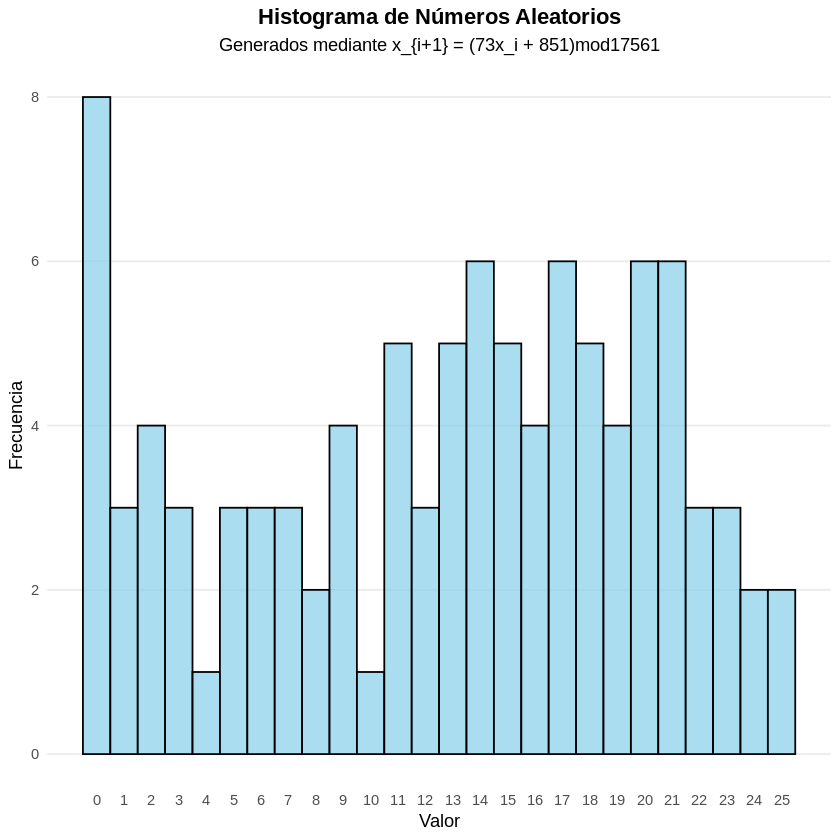

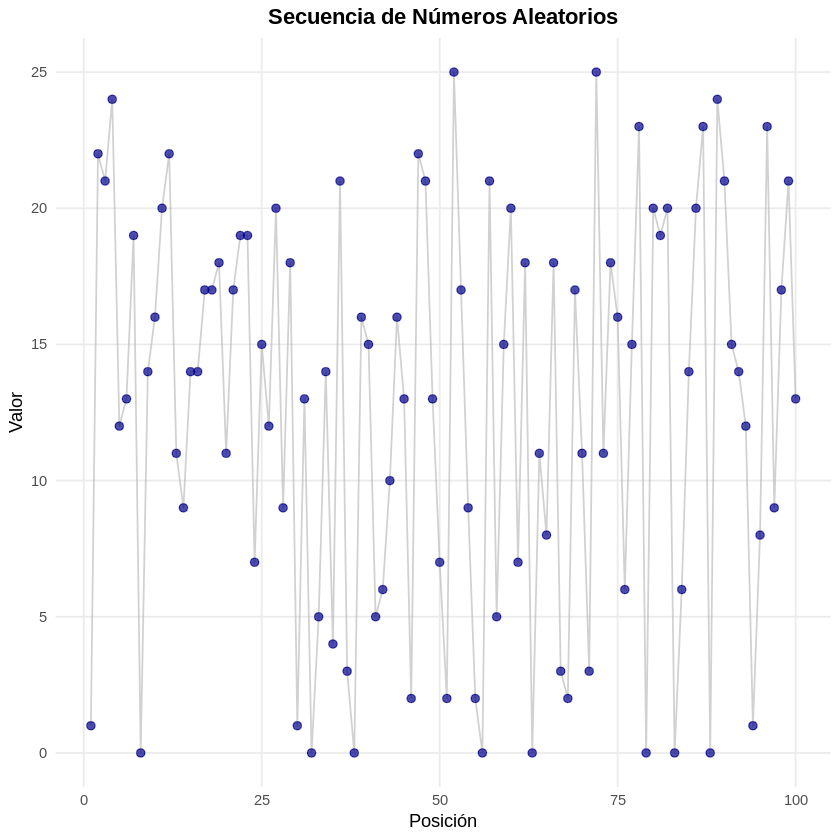

In [42]:
# Mostrar gráficos
print(graficos$histograma)
print(graficos$dispersion)